# Chapter 8: 알고리즘 트레이딩은 몸과 마음에 좋은가

마지막 장은 새 예측모형보다 왜 이 일을 하는지, 전략이 죽을 때 어떻게 살아남는지, 다른 사람의 돈을 어떤 구조로 운용하는지를 묻는다. 전용 Chapter 8 code/data ZIP은 없다. 따라서 입력이 없는 GLD-GDX 그림을 억지로 재현하지 않고, 본문이 함께 언급하는 GLD-USO를 공식 Chapter 5 ETF panel로 검증한다. 그 위에 active-day annualization, 거래비용, 전략 births/deaths, 별도계좌 integer allocation을 실험한다. lifestyle·사회적 효용·규제 서술은 수치 backtest가 아니다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
sys.path.insert(0,str(Path.cwd()))
import run_chapter8_analysis as ch8
data=ch8.load_data()
results=ch8.run_experiments(data)
checks=ch8.verify_results(data,results)
metrics=ch8.build_metrics(data,results,checks)
print(f"rows={len(data.dates):,}, checks={sum(checks.values())}/{len(checks)}")

rows=2,415, checks=24/24


## 1. 문제 정의와 학습 질문

첫째, “전략이 계속 수익성인가?”라는 질문에 어떤 시간 범위와 비용으로 답해야 하는가? 둘째, 포지션이 없는 날을 연율화 분모에서 빼면 성과가 얼마나 부풀어 오르는가? 셋째, 코드의 exit condition 한 줄이 책의 변수 설명과 다르면 무엇을 재현해야 하는가? 넷째, 죽어 가는 전략의 leverage를 줄이고 새 전략을 추가하는 lifecycle 규칙은 어떻게 look-ahead 없이 구현하는가? 다섯째, 작은 managed account가 정말 10개 전략을 담을 수 있는가?

In [2]:
def show_figure(fig):
    payload=BytesIO(); fig.savefig(payload,format='png',dpi=120,bbox_inches='tight'); plt.close(fig); display(Image(data=payload.getvalue()))
pd.DataFrame(ch8.coverage_matrix())

,topic,status,evidence
0,GLD-USO 20-day Bollinger,cross-book empirical replay,official Book 3 Ch5 panel; values identical to...
1,active-day annualization,source-metric audit,23.86% source clock versus 17.76% calendar clock
2,post-2012 strategy shelf life,temporal extension,915 later observations through 2015-11-25
3,source long-exit typo,code-semantic sensitivity,published Python uses -1 on the long exit whil...
4,strategy births/deaths and diversification,deterministic conceptual simulation,"10 strategies, two alpha breaks, seed pinned"
5,managed-account integer allocation,deterministic capacity illustration,four account sizes and ten margin requirements
6,GLD-GDX negative test,output-only,required 2006-2013 GDX panel absent
7,"health, service, and regulation",narrative/output-only,not a market-data calculation


## 2. 공식 archive 부재와 provenance

EP Chan의 Book 3 page는 Chapter 1~7 bundle을 제공하지만 Chapter 8 전용 archive는 없다. 이 노트북은 Chapter 5 공식 archive에서 SHA-256이 고정된 ETF MAT을 재사용한다. 또한 workspace의 Chan 2013 `bollinger.py`와 GLD-USO CSV가 있으면 각각 checksum을 검사하고, 1,500개 GLD·USO 값이 Book 3 panel과 완전히 같은지 확인한다. offline 실행도 모든 필수 byte를 검증한다.

In [3]:
pd.Series({**metrics['provenance'],'uv_lock_sha256':metrics['environment']['uv_lock_sha256'],'versions':metrics['environment']['versions']})

source_page                                                      https://epchan.com/book3
official_chapter_8_archive_available                                                False
reused_official_archive_chapter                                                         5
reused_data_path                        data/raw/book3/chapter_5/inputDataOHLCDaily_ET...
reused_data_sha256                      939245babc96c8dad661b6676ba3f07ea2b9d7b6ec627e...
reused_data_size_bytes                                                            1707986
chapter_text_sha256                     27959d06800ba7e2d4884fca047955941e16d1c4035a8c...
cross_book_source_path                  archive/Chan E. Algorithmic Trading - Winning ...
cross_book_source_present                                                            True
cross_book_source_sha256                99b8a6e8d40389130f4bcead274b1b45280b16491149ea...
cross_book_data_path                    archive/Chan E. Algorithmic Trading - Winning ...
cross_book

## 3. 재현 상태와 coverage matrix

`exact cross-book replay`는 Ch8 자체 출력이 아니라 Chan 2013 data와 수정된 chapter analyzer의 숫자에 대한 정확 일치다. `empirical extension`은 같은 계약을 2012-2015에 새로 적용한다. `conceptual simulation`은 시장 성과 주장이 아닌 운영 원리의 합성 fixture다. `output-only`는 GDX 입력 부재, 비수치 health claim, 낡을 수 있는 법률 서술을 뜻한다. 이 좁은 분류가 과대표기를 막는다.

In [4]:
pd.Series(metrics['reproduction_classification']).apply(lambda x:', '.join(x))

exact_cross_book_replay                 corrected GLD-USO active-day metrics
empirical_extension                                        GLD-USO 2012-2015
conceptual_simulation        strategy lifecycle, managed-account granularity
output_only                GLD-GDX fixed-spread strategy death, health, a...
dtype: str

## 4. 데이터 구조와 결측 진단

공식 ETF panel은 26개 asset을 담고 사용 구간의 GLD·USO는 finite·positive다. 날짜가 엄격히 증가하고 중복이 없는지 확인한다. 2006-04-26~2012-04-09는 cross-book CSV 1,500행과 값이 같고, 2012-04-10~2015-11-25는 915행 temporal extension이다. GDX는 panel에 없으므로 Figure 8.1의 negative out-of-sample curve를 실행 결과로 만들 수 없다.

rows                           2415
date_start                 20060426
date_end                   20151125
official_panel_assets            26
gld_missing_used_period           0
uso_missing_used_period           0
gdx_available                 False
dtype: object

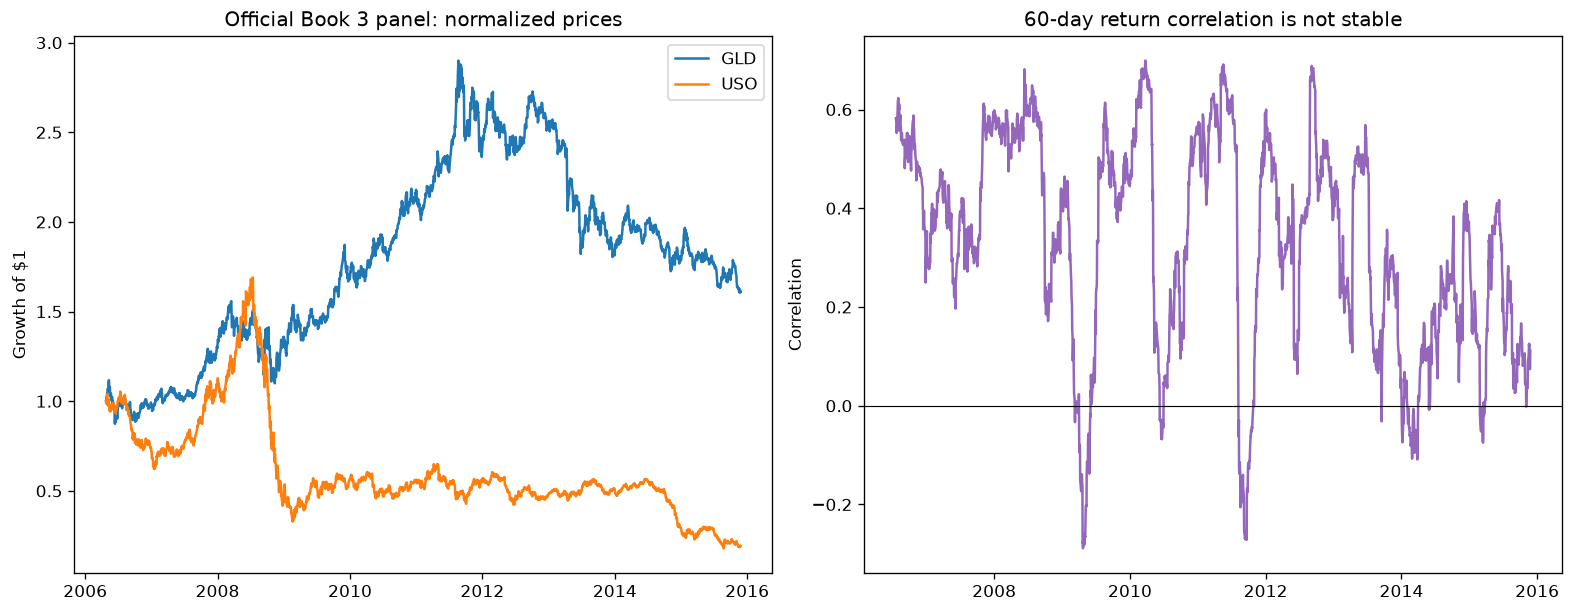

In [5]:
display(pd.Series(metrics['data'])); show_figure(ch8.plot_data(data))

## 5. 수식 → 코드: dynamic spread

최근 20일에서

$$USO_t=\alpha_t+\beta_t GLD_t+\epsilon_t, \qquad S_t=USO_t-\beta_t GLD_t$$

를 계산한다. `rolling_hedge_ratio()`의 window는 현재 종가까지 포함하지만 position은 다음 날 return에 적용된다. 따라서 close-to-close 구현은 미래 return을 사용하지 않는다. 같은 거래일 close에서 signal을 계산하고 그 close에 체결할 수 있다는 가정은 남으므로 실전에서는 다음 open 또는 latency-aware fill을 별도 검증해야 한다.

In [6]:
pd.Series(results['gld_uso']['original_period']['contract'])

lookback_days                                    20
entry_zscore                                    1.0
exit_zscore                                     0.0
rolling_standard_deviation_ddof                   1
positions_are_lagged_one_day                   True
source_active_day_clock_excludes_flat_days     True
source_long_exit_bug_replayed                 False
transaction_cost_per_unit_change              0.001
dtype: object

## 6. 수식 → 코드: Bollinger state machine

$$z_t=\frac{S_t-\overline S_{t,20}}{s_{t,20}}.$$

$z<-1$이면 long spread, $z>1$이면 short spread, 평균선 0에서 청산한다. sample standard deviation `ddof=1`을 사용한다. `positions_from_zscore()`는 NaN 상태를 forward-fill하고, `bollinger_strategy()`는 $q_{t-1}$로 $t$일 return을 계산한다. long과 short의 진입·청산 부등식 및 경계가 명시적인 contract다.

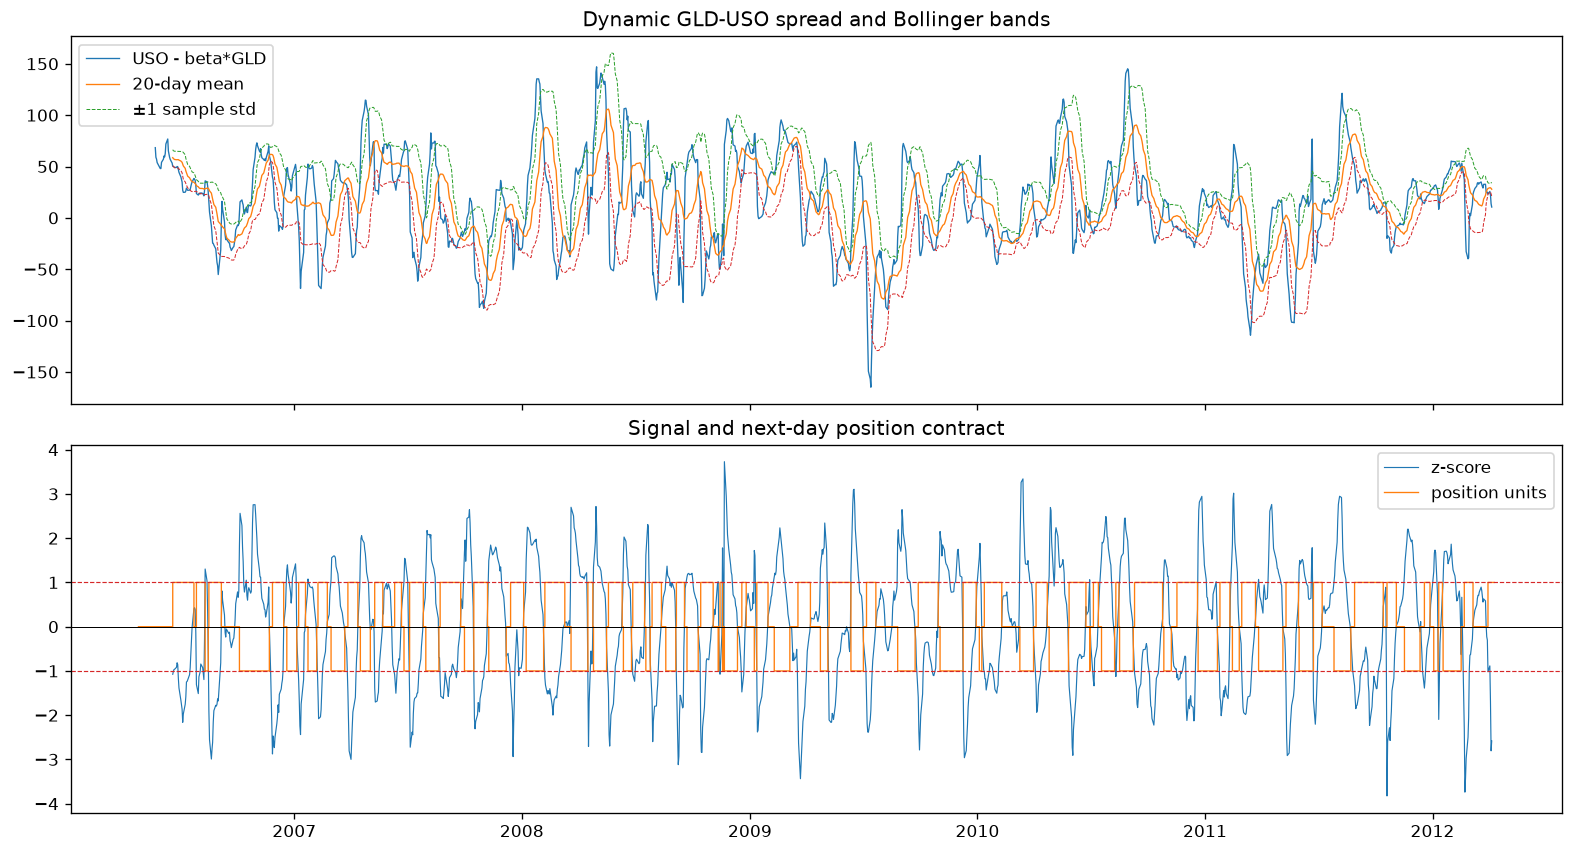

In [7]:
show_figure(ch8.plot_bollinger(results))

## 7. cross-book 원본 비교

APR, Sharpe, maximum drawdown 세 숫자를 1e-12 tolerance로 비교한다. 이 숫자는 수정된 mean-exit 구현과 active-day clock의 조합이다. 데이터는 exact이지만 Chapter 8 출판 output은 아니므로 `Machine Trading Ch8 exact`라고 부르지 않는다. source 범위, data 범위, metric clock을 모두 붙여야 재현 주장이 검증 가능하다.

In [8]:
pd.DataFrame(metrics['book_comparisons'])

,topic,metric,python,source,absolute_error,tolerance,classification,matches_source
0,Chan 2013 GLD-USO Bollinger cross-book replay,annual_return,0.238609,0.238609,0.0,1.000000e-12,exact replay of the corrected chapter-analysis...,True
1,Chan 2013 GLD-USO Bollinger cross-book replay,sharpe,1.106654,1.106654,0.0,1.000000e-12,exact replay of the corrected chapter-analysis...,True
2,Chan 2013 GLD-USO Bollinger cross-book replay,maximum_drawdown,-0.218318,-0.218318,0.0,1.000000e-12,exact replay of the corrected chapter-analysis...,True


## 8. active-day annualization 편향

원본 chapter analyzer는 포지션이 없을 때 분모가 0인 return을 NaN으로 만들고 drop한 뒤 252일 연율화한다. 1,500 calendar days 중 1,146 active days만 분모에 남아 APR이 23.86%가 된다. flat day를 0 return으로 포함하면 17.76%다. 자본이 다른 곳에 완전히 재배치되었다는 명시적 모델이 없으면 inactive day도 투자 horizon에 포함하는 편이 보수적이다.

In [9]:
pd.DataFrame({'source_active_day':results['gld_uso']['original_period']['source_active_day'],'calendar_gross':results['gld_uso']['original_period']['calendar_gross'],'calendar_net_10bps':results['gld_uso']['original_period']['calendar_net_10bps']}).T

,cumulative_return,annual_return,sharpe,maximum_drawdown,drawdown_duration,periods
source_active_day,1.646242,0.238609,1.106654,-0.218318,180.0,1146.0
calendar_gross,1.646242,0.177611,0.966839,-0.218318,252.0,1500.0
calendar_net_10bps,1.230752,0.144300,0.813822,-0.229144,276.0,1500.0


## 9. source long-exit typo

Chan 2013 `bollinger.py`는 `exitZscore=0`을 선언해 놓고 long exit에 `zScore > -entryZscore`를 쓴다. short exit은 0을 쓴다. 이는 symmetric mean exit 설명과 다르다. typo-faithful 경로와 corrected 경로를 둘 다 실행해 cumulative return, turnover, drawdown 차이를 공개한다. 코드 주석이나 변수 이름이 실제 boolean branch보다 우선할 수 없다.

In [10]:
pd.DataFrame({'corrected_mean_exit':results['gld_uso']['original_period']['calendar_gross'],'source_long_exit_typo':results['gld_uso']['source_code_long_exit_bug']['calendar_gross']}).T

,cumulative_return,annual_return,sharpe,maximum_drawdown,drawdown_duration,periods
corrected_mean_exit,1.646242,0.177611,0.966839,-0.218318,252.0,1500.0
source_long_exit_typo,1.134326,0.135837,0.811841,-0.169348,263.0,1500.0


## 10. 거래비용과 clock-time 성과

$$r_t^{net}=r_t-0.001\lvert q_t-q_{t-1}\rvert.$$

10bp는 spread·borrow·impact를 모두 포괄하는 현실적 모델이 아니라 최소 stress다. signal이 바뀌는 날 unit turnover에 부과한다. gross와 net을 같은 calendar clock으로 비교해 비용이 성과를 개선하지 않는지 자동 검증한다. 실제 두 ETF를 dollar-neutral하게 맞추는 주문 수량, bid-ask, fractional share 가능성은 추가 실행 제약이다.

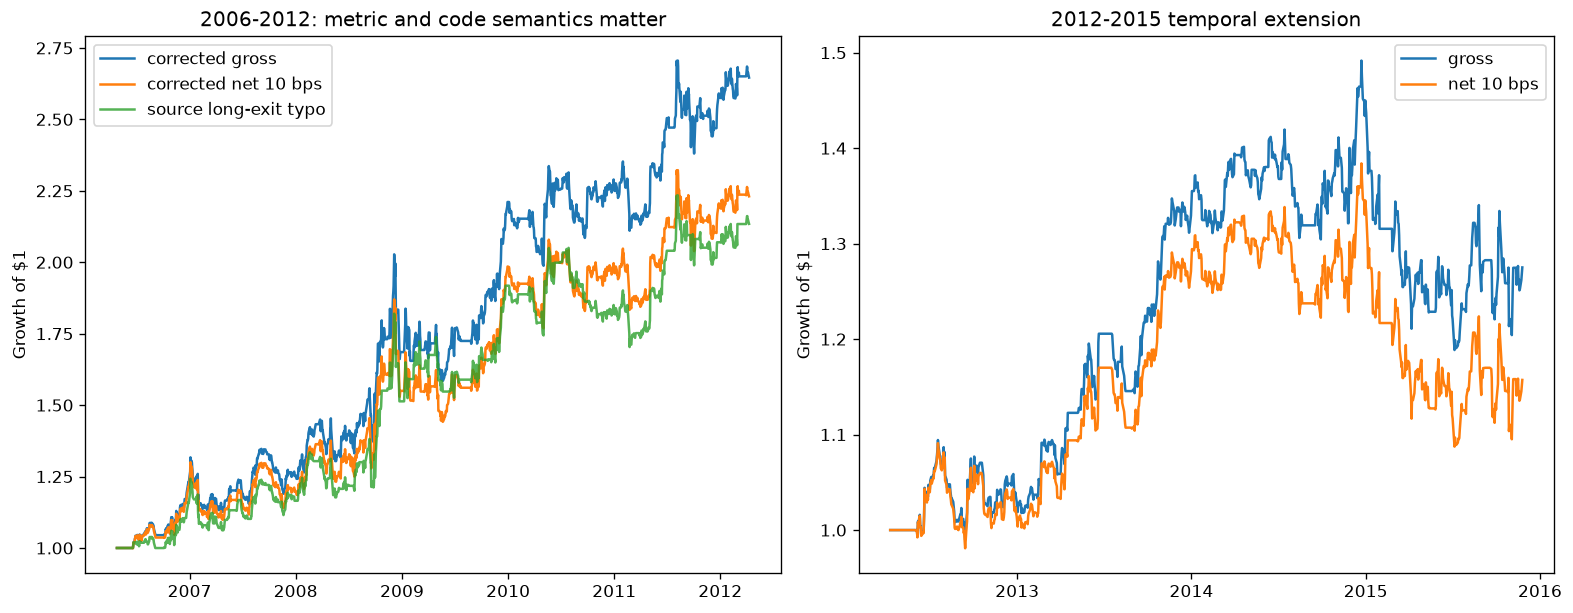

In [11]:
show_figure(ch8.plot_strategy_shelf_life(results))

## 11. 2006-2012 결과 해석

수정된 mean-exit 전략은 calendar gross APR 17.76%, 10bp 후 14.43%, net max drawdown 약 -22.9%다. 이 수치는 당시 data에서 전략이 양수였다는 역사적 결과다. hedge ratio, lookback 20, entry 1, exit 0이 같은 연구 역사에서 선택되었다면 selection bias가 남는다. survivorship bias, vendor correction, adjusted price convention도 범위 밖이다.

In [12]:
pd.DataFrame({'original_gross':results['gld_uso']['original_period']['calendar_gross'],'original_net':results['gld_uso']['original_period']['calendar_net_10bps'],'extension_gross':results['gld_uso']['post_book_extension']['calendar_gross'],'extension_net':results['gld_uso']['post_book_extension']['calendar_net_10bps']}).T

,cumulative_return,annual_return,sharpe,maximum_drawdown,drawdown_duration,periods
original_gross,1.646242,0.177611,0.966839,-0.218318,252.0,1500.0
original_net,1.230752,0.144300,0.813822,-0.229144,276.0,1500.0
extension_gross,0.275077,0.069217,0.545448,-0.203226,233.0,915.0
extension_net,0.157253,0.041043,0.355915,-0.214329,233.0,915.0


## 12. 2012-2015 temporal extension

동일 계약을 2012-04-10에 상태를 reset하고 2015-11-25까지 적용하면 gross와 10bp net APR 모두 플러스지만 이전 기간보다 낮다. 상태 reset은 실제 연속 운용과 다르므로 full-period curve도 함께 제공한다. 이 extension은 책의 “continues to have positive returns”라는 당시 서술을 제한적으로 지지하지만, 2015 이후 또는 현재 수익성을 말하지 않는다.

In [13]:
pd.DataFrame(results['strategy_lifecycle']['performance']).T

,cumulative_return,annual_return,sharpe,maximum_drawdown,drawdown_duration,periods
concentrated_dying_strategy,-0.594543,-0.203470,-1.733876,-0.618524,878.0,1000.0
equal_weight_live_pool,0.132845,0.031932,0.633544,-0.060229,283.0,1000.0
drawdown_budget_live_pool,0.364722,0.081512,1.246255,-0.069138,217.0,1000.0


## 13. 전략 births/deaths simulation

10개 synthetic strategy의 공통 factor와 idiosyncratic shock을 만들고 strategy 0은 day 500, strategy 1은 day 700 이후 기대수익을 악화시킨다. 다른 strategy는 순차적으로 태어난다. 단일 dying strategy, active strategy equal-weight pool, lagged drawdown-budget pool을 비교한다. seed=20260718을 고정하지만 이 결과는 시장 backtest가 아니라 diversification과 state transition을 보여 주는 개념 실험이다.

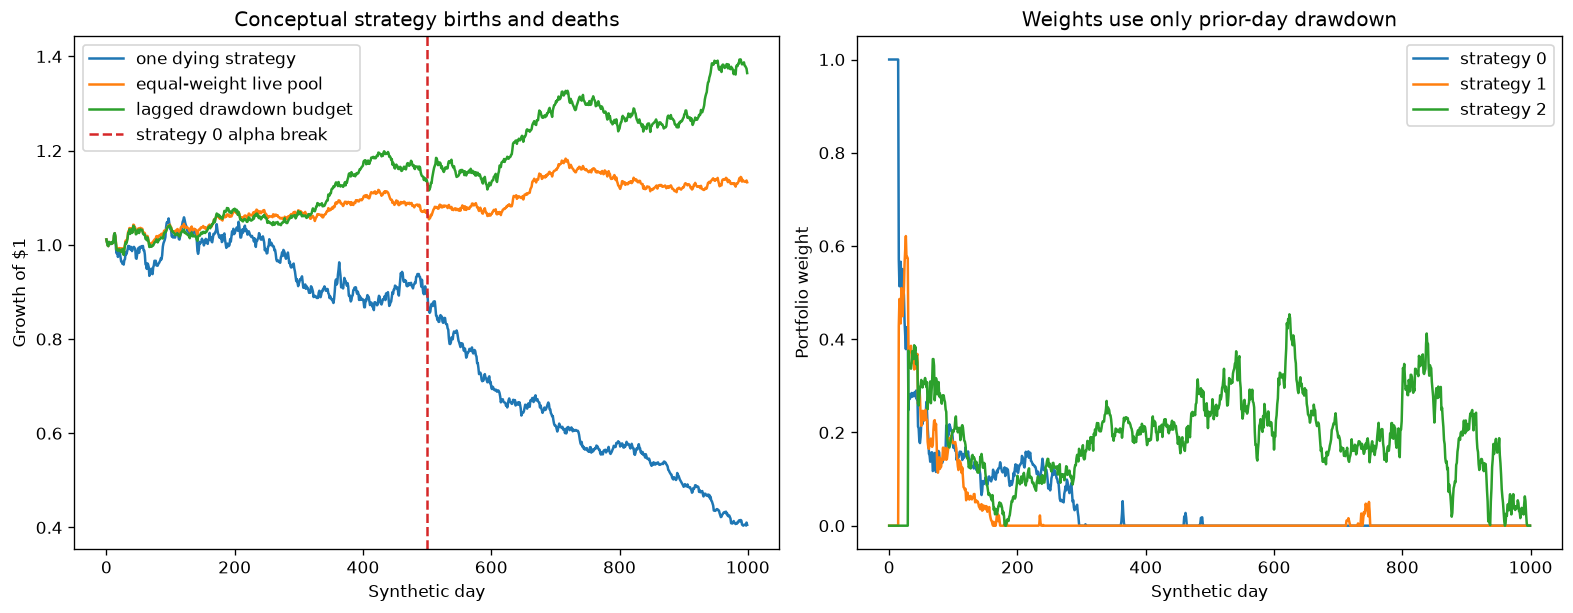

In [14]:
show_figure(ch8.plot_strategy_lifecycle(results))

## 14. drawdown budget와 look-ahead 방지

각 strategy의 전일까지 wealth/peak로 drawdown을 계산하고 -12%에서 budget을 0으로 줄인다. 오늘 return은 weight 결정 뒤에 반영한다. 따라서 미래 성과를 보고 죽은 전략을 제거하지 않는다. adaptive curve가 equal-weight보다 좋아도 특정 seed의 산물이며, threshold를 합성 결과에 맞춰 최적화하지 않는다. 실전에서는 false stop과 재진입 기준, strategy correlation spike를 더 검증해야 한다.

In [15]:
pd.DataFrame(results['managed_account_granularity']['rows'])

,account_size_usd,strategies_with_nonzero_allocation,capital_utilization,l1_weight_error
0,25000.0,0,0.000,1.000
1,100000.0,4,0.305,0.695
2,500000.0,10,0.888,0.112
3,2000000.0,10,0.982,0.018


## 15. managed-account integer allocation

10개 전략의 illustrative margin requirement와 네 account size를 둔다. 목표는 전략당 10%지만 target dollar가 한 계약 margin보다 작으면 0계약이다. 25k 계정은 어느 전략도 담지 못하고, 100k도 일부만 담는다. 500k 이상에서 모두 nonzero가 되지만 weight error는 남는다. margin 숫자는 시장 quote가 아니고, account structure의 capacity mechanism만 보여 준다.

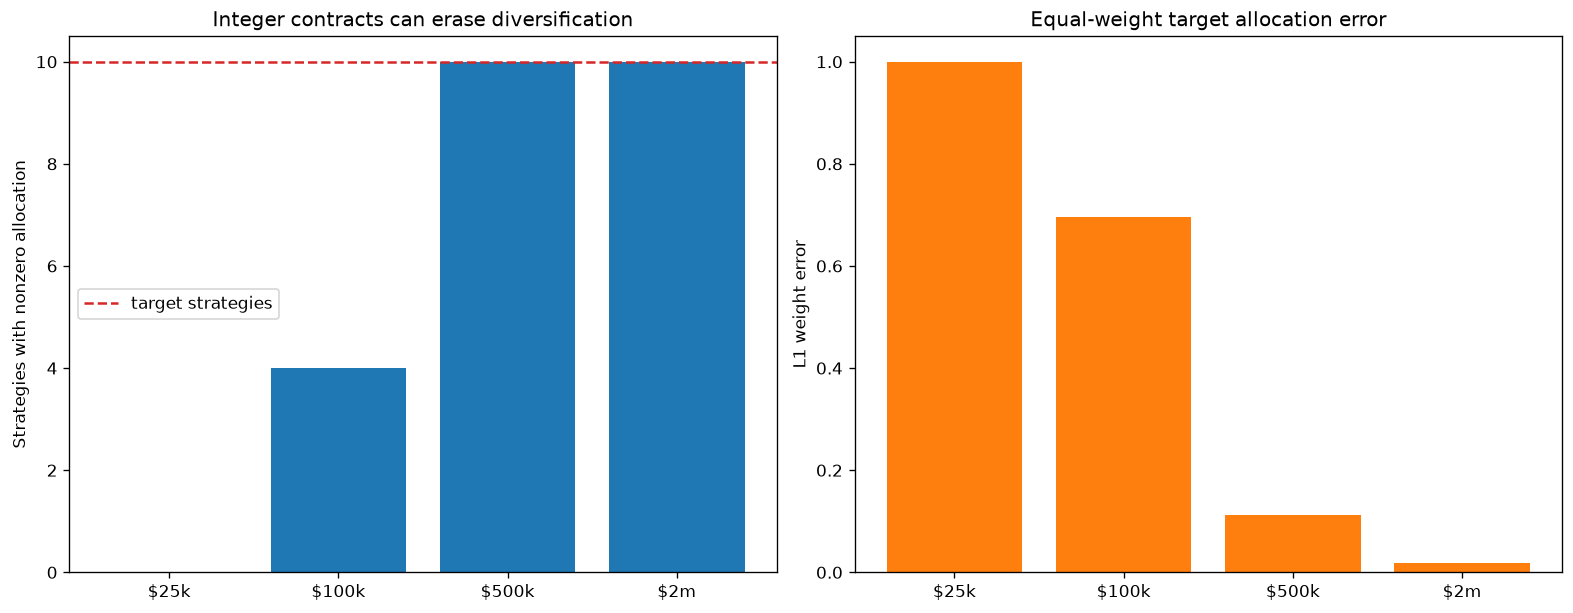

In [16]:
show_figure(ch8.plot_account_granularity(results))

## 16. principal-agent와 운영 구조

managed account는 자금 통제와 투명성이 높지만 trade secret이 노출되고 작은 계정의 계약 배분이 거칠다. fund는 작은 strategy allocation을 pool할 수 있지만 custody·audit·administration·규제 부담이 다르다. manager가 자기자본을 함께 투자하지 않으면 risk-taking incentive가 어긋날 수 있다. 이 노트북은 integer granularity만 계산하며 어느 구조가 법적으로 적합한지 판단하지 않는다.

## 17. output-only 및 법률·건강 주의

GLD-GDX 2006-2013 test negative라는 방향, 나쁜 상사·통근·앉아 있기·반려동물에 관한 건강 서술, 2016년 registration threshold와 provider 목록은 계산하지 않는다. 특히 법률과 사업자 상태는 시간이 지나며 바뀌므로 현재 advice로 재사용할 수 없다. source text를 인용하는 것과 오늘도 사실이라고 검증하는 것은 다른 작업이다.

In [17]:
pd.DataFrame(metrics['reference_only_comparisons'])[['topic','compared','reason']]

,topic,compared,reason
0,GLD-GDX fixed-spread strategy death,False,Chapter 8 publishes a figure and directional s...
1,"health, autonomy, and productivity claims",False,these are narrative and cited lifestyle claims...
2,managed-account registration thresholds and se...,False,the chapter describes a 2016 legal and busines...


## 18. 위험지표와 out-of-sample 범위

APR·Sharpe·maximum drawdown·drawdown duration을 gross/net과 active/calendar clock별로 기록한다. 2012-2015 extension은 시간상 뒤지만 하나의 추가 window일 뿐 반복 가능한 walk-forward 검증은 아니다. GLD-USO 자체가 두 ETF의 경제적 관계에 의존하고 USO는 futures roll의 영향을 받는다. 전략 shelf life는 한 번의 positive extension으로 확정할 수 없다.

In [18]:
pd.Series({'random_seed':ch8.RANDOM_SEED,'generator':'PCG64','weights_lagged':results['strategy_lifecycle']['contract']['weights_use_information_through_previous_day'],'notebook_cell_ids':'deterministic'})

random_seed               20260718
generator                    PCG64
weights_lagged                True
notebook_cell_ids    deterministic
dtype: object

## 19. deterministic contract와 자동 verification

PCG64 seed, fixed simulation dimensions, deterministic cell ID와 PNG metadata를 고정한다. 자동 검증은 SHA-256, Chapter 8 archive 부재 공개, GLD/USO/GDX coverage, date·price, 1,500/915 rows, exact source metrics, active-day clock, position lag, cost monotonicity, exit typo 차이, lifecycle weight timing, account granularity와 output-only 사유를 검사한다. 모든 assert가 참이어야 산출물을 완성한다.

In [19]:
verification=pd.Series(checks,name='passed'); display(verification); assert verification.all(); print(f"verification passed: {verification.sum()}/{len(verification)}")

reused_official_data_checksum_matches           True
chapter_8_archive_absence_is_explicit           True
gld_and_uso_are_in_official_panel               True
gdx_absence_is_disclosed                        True
dates_are_strictly_increasing                   True
all_used_prices_are_finite_positive             True
original_cross_book_period_has_1500_rows        True
cross_book_data_values_match_when_available     True
post_book_extension_has_915_rows                True
source_active_day_outputs_match                 True
source_active_day_clock_is_disclosed            True
calendar_clock_is_more_conservative             True
positions_are_lagged_one_day                    True
transaction_costs_reduce_original_return        True
extension_remains_positive_before_cost          True
extension_remains_positive_after_10bps          True
source_long_exit_typo_changes_results           True
lifecycle_seed_is_pinned                        True
lifecycle_weights_are_lagged                  

verification passed: 24/24


## 20. 결론

이 장의 핵심은 전략 하나의 영속성을 증명하는 것이 아니다. 실제 재현은 metric clock과 exit typo가 같은 data의 성과를 크게 바꾼다는 점을 보여 준다. temporal extension은 플러스지만 약해졌고 2015에서 끝난다. 합성 실험은 dying strategy 집중보다 독립 pool과 사전 정의된 leverage reduction이 견고함을 보여 준다. 마지막으로 작은 account는 정수 계약 때문에 이론적 분산을 구현하지 못한다. 연구, 실행, business structure를 하나의 lifecycle로 관리해야 한다.